# SCOPUS

## IMPORTAR LIBRERÍAS

In [94]:
# Analisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBRegressor

# Exportar el modelo entrenado
import joblib
import re
from scipy.sparse import hstack

In [95]:
df = pd.read_csv("/content/drive/MyDrive/FUNDAMENTOS DE MACHINE LEARNING/PA3/scopus.csv")
df.head()

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,DOI,Link,Abstract,Author Keywords,Index Keywords,Document Type,Publication Stage,Open Access,Source,EID
0,Wojcik-Czerniawska A.,"Wojcik-Czerniawska, Agnieszka (57936855200)",57936855200,Exploring Human Resource Innovations in E-Economy,2026,Exploring Human Resource Innovations in E-Economy,NaN,NaN,NaN,1.0,...,NaN,https://www.scopus.com/pages/publications/1050...,"In the e-economy, organizations change human r...",NaN,Competition; Employment; Information managemen...,Book,Final,NaN,Scopus,2-s2.0-105038172749
1,Nakash M.; Peretz O.,"Nakash, Maayan (57220960624); Peretz, Or (5780...",57220960624; 57800240100,Decoding the AI job market: mapping skills and...,2025,Employee Relations,NaN,NaN,NaN,1.0,...,10.1108/ER-07-2025-0566,https://www.scopus.com/pages/publications/1050...,Purpose – The rapid advancement of artificial ...,Artificial intelligence; Digital labor market;...,NaN,Article,Article in press,NaN,Scopus,2-s2.0-105025465060
2,Fernando P.R.R.,"Fernando, Pattinige Ravindra R (57222526052)",57222526052,Improving the quality of education system usin...,2020,CITISIA 2020 - IEEE Conference on Innovative T...,NaN,NaN,9371793,NaN,...,10.1109/CITISIA50690.2020.9371793,https://www.scopus.com/pages/publications/8510...,Education is the most important and silent wea...,Big data in education; Business intelligence; ...,Data Analytics; Data Science; Data warehouses;...,Conference paper,Final,NaN,Scopus,2-s2.0-85103050305
3,Shailaja M.; Lanka L.; Soma K.; Kumar E.S.; Pr...,"Shailaja, M. (58654425300); Lanka, Lavanya (57...",58654425300; 57877232700; 58236903600; 5871690...,Developing a SVM Model of Big Data Analytics f...,2023,"Smart Innovation, Systems and Technologies",363,NaN,NaN,159.0,...,10.1007/978-981-99-4717-1_15,https://www.scopus.com/pages/publications/8517...,"Today, the data world that rules us made its m...",Big data analytics; Electronic health records;...,Big data; Commerce; Data Analytics; Patient tr...,Conference paper,Final,NaN,Scopus,2-s2.0-85174444500
4,Baig M.A.; Alzahrani S.J.,"Baig, Mansoor Ali (57201642589); Alzahrani, So...",57201642589; 57209736606,Revisiting the Skills of a Healthcare Data Sci...,2019,Studies in Health Technology and Informatics,262,NaN,NaN,43.0,...,10.3233/SHTI190012,https://www.scopus.com/pages/publications/8506...,The buzz words 'Data Science' and 'Data Scient...,Advanced Analytics; Data Management; Data Scie...,Comprehension; Data Science; Decision Making; ...,Conference paper,Final,NaN,Scopus,2-s2.0-85068550523


## Limpieza de datos

In [96]:
df.describe()

,Year,Issue,Page start,Page end,Cited by
count,41.000000,9.000000,33.000000,33.000000,41.000000
mean,2021.536585,2.888889,225.212121,329.121212,14.878049
std,2.933407,1.364225,324.907560,302.991415,39.666860
min,2014.000000,1.000000,1.000000,3.000000,0.000000
25%,2020.000000,2.000000,1.000000,108.000000,0.000000
50%,2021.000000,3.000000,85.000000,201.000000,2.000000
75%,2024.000000,4.000000,359.000000,497.000000,7.000000
max,2026.000000,5.000000,1329.000000,1336.000000,212.000000


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Authors            41 non-null     object 
 1   Author full names  41 non-null     object 
 2   Author(s) ID       41 non-null     object 
 3   Title              41 non-null     object 
 4   Year               41 non-null     int64  
 5   Source title       41 non-null     object 
 6   Volume             20 non-null     object 
 7   Issue              9 non-null      float64
 8   Art. No.           6 non-null      object 
 9   Page start         33 non-null     float64
 10  Page end           33 non-null     float64
 11  Cited by           41 non-null     int64  
 12  DOI                38 non-null     object 
 13  Link               41 non-null     object 
 14  Abstract           41 non-null     object 
 15  Author Keywords    28 non-null     object 
 16  Index Keywords     29 non-nu

In [98]:
df.columns

Index(['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
       'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end',
       'Cited by', 'DOI', 'Link', 'Abstract', 'Author Keywords',
       'Index Keywords', 'Document Type', 'Publication Stage', 'Open Access',
       'Source', 'EID'],
      dtype='object')

In [99]:
# Limpiar nombres de columnas
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(r'[^a-zA-Z0-9_]', '', regex=True)
)

df.columns

Index(['authors', 'author_full_names', 'authors_id', 'title', 'year',
       'source_title', 'volume', 'issue', 'art_no', 'page_start', 'page_end',
       'cited_by', 'doi', 'link', 'abstract', 'author_keywords',
       'index_keywords', 'document_type', 'publication_stage', 'open_access',
       'source', 'eid'],
      dtype='object')

In [100]:
df = df.drop(columns=[
    'link',
    'art_no',
    'page_start',
    'page_end',
    'publication_stage'
], errors='ignore')

In [101]:
df.isnull().sum().sort_values(ascending=False)

,0
issue,32
open_access,31
volume,21
author_keywords,13
index_keywords,12
doi,3
authors,0
author_full_names,0
authors_id,0
cited_by,0


In [102]:
# Completar columnas de texto
df['author_keywords'] = df['author_keywords'].fillna('')
df['index_keywords'] = df['index_keywords'].fillna('')
df['doi'] = df['doi'].fillna('No_DOI')

# Completar columnas numéricas/categóricas
df['volume'] = df['volume'].fillna(df['volume'].mode()[0])

# Issue puede ser texto o número según la revista
df['issue'] = df['issue'].fillna(df['issue'].mode()[0])

# Open Access
df['open_access'] = df['open_access'].fillna('Unknown')

In [103]:
df.isnull().sum().sort_values(ascending=False)

,0
authors,0
author_full_names,0
authors_id,0
title,0
year,0
source_title,0
volume,0
issue,0
cited_by,0
doi,0


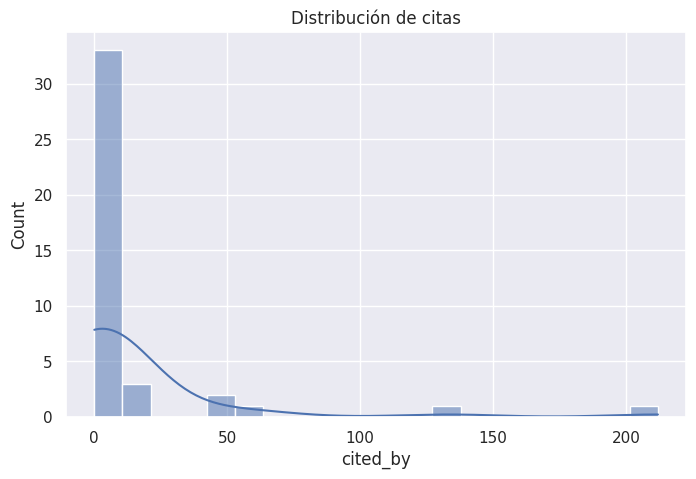

In [104]:
# Distribución sesgada
plt.figure(figsize=(8,5))

sns.histplot(df['cited_by'], bins=20, kde=True)

plt.title('Distribución de citas')
plt.show()

In [105]:
Q1 = df['cited_by'].quantile(0.25)
Q3 = df['cited_by'].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

print("Límite superior:", lim_sup)

Límite superior: 17.5


In [106]:
df['cited_by_log'] = np.log1p(df['cited_by'])

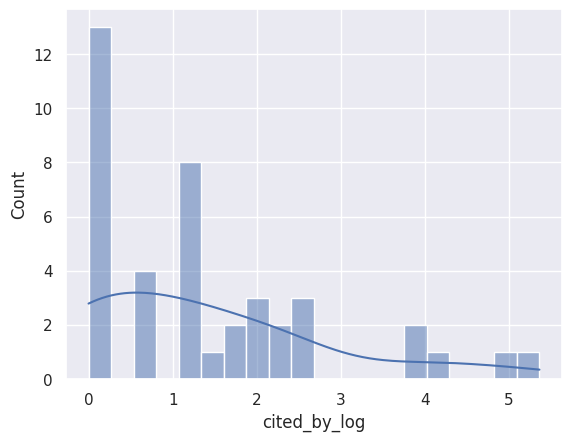

In [107]:
sns.histplot(df['cited_by_log'], bins=20, kde=True)
plt.show()

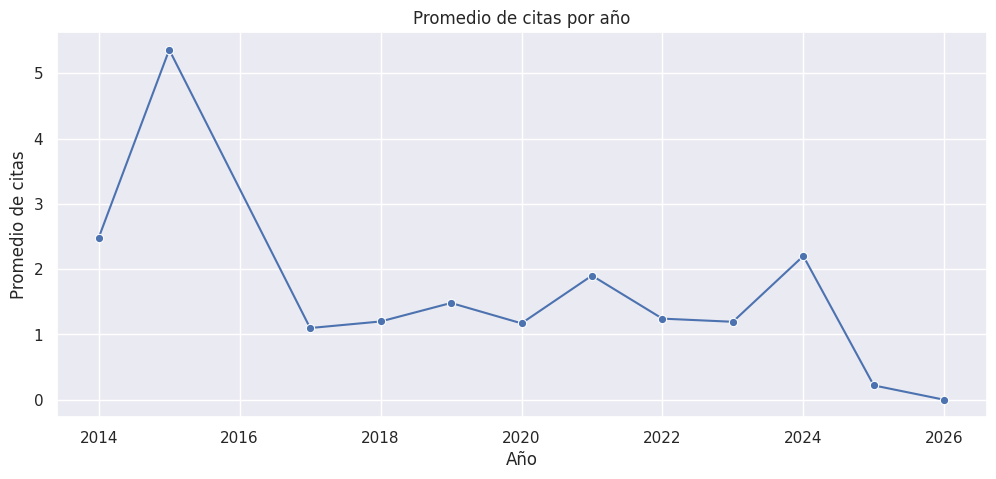

In [108]:
# Promedio de citas por año
citas_anio = df.groupby('year')['cited_by_log'].mean().reset_index()

plt.figure(figsize=(12,5))

sns.lineplot(
    data=citas_anio,
    x='year',
    y='cited_by_log',
    marker='o'
)

plt.title('Promedio de citas por año')
plt.xlabel('Año')
plt.ylabel('Promedio de citas')

plt.show()

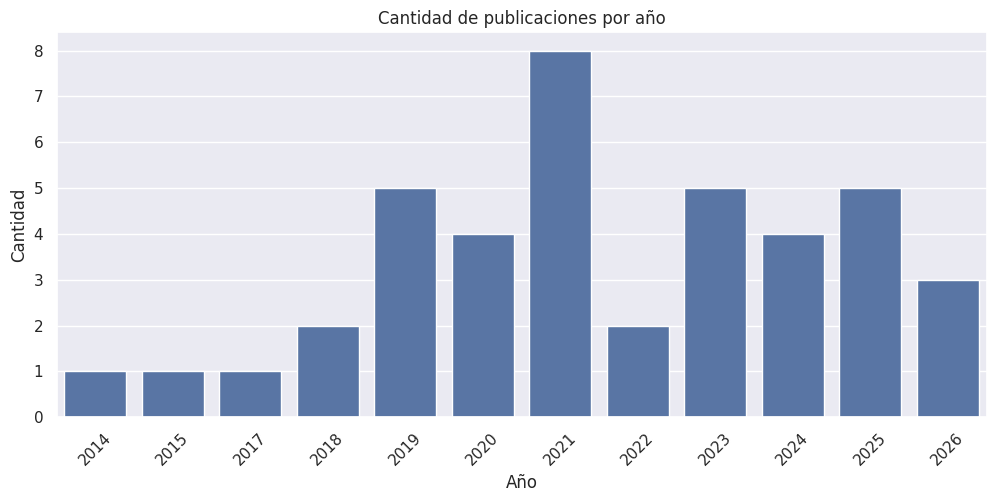

In [109]:
# Evolución de publicaciones por año
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='year',
    order=sorted(df['year'].dropna().unique())
)

plt.xticks(rotation=45)
plt.title('Cantidad de publicaciones por año')
plt.xlabel('Año')
plt.ylabel('Cantidad')

plt.show()